In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# from armain import Perceptron, Adeline, LogisticRegression

In [5]:
llist = [1, 2, 3, 4, 5]

In [6]:
llist.extend([1, 2, 3, 4])
llist

[1, 2, 3, 4, 5, 1, 2, 3, 4]

In [7]:
np.hstack([[1, 2, 3], [4, 5, 6]])

array([1, 2, 3, 4, 5, 6])

In [6]:
import math


math.comb(10, 2) * 50

2250

In [5]:
zz = np.zeros(10)
zz

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [9]:
a = [1, 2, 3]

In [15]:
sett = set()

pd.Series({1: 'sdfs asdf', 2: 'asdfas fsdf', 3:'sfvdcsv dfsdfsa'}).map(lambda x: sett.update(set(x.split())))

1    None
2    None
3    None
dtype: object

In [45]:
from sklearn.feature_extraction.text import CountVectorizer 

count = CountVectorizer() 
docs = np.array(['The sun is shining', 'The weather is sweet', 'The sun is shining, the weather is sweet, and one and one is two'])

bag = count.fit_transform(docs)

In [48]:
count.vocabulary_

{'the': 6,
 'sun': 4,
 'is': 1,
 'shining': 3,
 'weather': 8,
 'sweet': 5,
 'and': 0,
 'one': 2,
 'two': 7}

In [33]:
bag = bag.toarray()

In [37]:
tf = bag.sum(axis=0)
tf

array([2, 5, 2, 2, 2, 2, 4, 1, 2], dtype=int64)

In [38]:
tf = tf / np.linalg.norm(tf)

In [39]:
tf

array([0.25, 0.62, 0.25, 0.25, 0.25, 0.25, 0.49, 0.12, 0.25])

In [42]:
idf = np.log((len(bag) + 1) / (1 + np.count_nonzero(bag, axis=0)))
tf_idf = tf * (idf + 1)

ModuleNotFoundError: No module named 'torch'

In [44]:
tf_idf

array([0.42, 0.62, 0.42, 0.32, 0.32, 0.32, 0.49, 0.21, 0.32])

In [43]:
np.round(bag * tf_idf, 2)

array([[0.  , 0.62, 0.  , 0.32, 0.32, 0.  , 0.49, 0.  , 0.  ],
       [0.  , 0.62, 0.  , 0.  , 0.  , 0.32, 0.49, 0.  , 0.32],
       [0.83, 1.85, 0.83, 0.32, 0.32, 0.32, 0.98, 0.21, 0.32]])

In [29]:
bag

array([[0, 1, 0, 1, 1, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 1, 1, 0, 1],
       [2, 3, 2, 1, 1, 1, 2, 1, 1]], dtype=int64)

In [ ]:
import math
math.factorial

In [31]:
from sklearn.feature_extraction.text import TfidfTransformer 
tfidf = TfidfTransformer(use_idf=True, norm='l2', smooth_idf=True) 
np.set_printoptions(precision=2) 
tfidf.fit_transform(count.fit_transform(docs)).toarray()

array([[0.  , 0.43, 0.  , 0.56, 0.56, 0.  , 0.43, 0.  , 0.  ],
       [0.  , 0.43, 0.  , 0.  , 0.  , 0.56, 0.43, 0.  , 0.56],
       [0.5 , 0.45, 0.5 , 0.19, 0.19, 0.19, 0.3 , 0.25, 0.19]])

In [ ]:
end_date = pd.to_datetime('2019-07-27')
start_date = end_date - pd.DateOffset(30)
start_date
pd.Series().up

Timestamp('2019-06-27 00:00:00')

In [ ]:
np.ndarray() np.isnan

In [66]:
iris = sns.load_dataset('iris')

In [ ]:
np.vstack()

In [67]:
transformer_pipe = make_pipeline(RobustScaler(),
                                 StandardScaler(),
                                 PCA(n_components=2),)

encoder = LabelEncoder()

In [68]:
iris_features = ['sepal_length', 'sepal_width',	'petal_length',	'petal_width']
iris_targets = 'species'

In [4]:
a = 0.3123124
print(f"{a: .2f}")

 0.31


In [ ]:
pd.DataFrame()

In [69]:
X = transformer_pipe.fit_transform(iris[iris_features].to_numpy())
y = encoder.fit_transform(iris[iris_targets].to_numpy())

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True,test_size=0.2, stratify=y)

In [71]:
folds = StratifiedKFold(n_splits=10, shuffle=True).split(X_train, y_train)

In [62]:
model = LogisticRegression(max_iter=1)

In [41]:
from sklearn.base import clone

In [ ]:
import math
math.isclose

0.30000000000000004

In [63]:
epoch = 10
training_accuracy = np.zeros(10)
validation_accuracy = np.zeros(10)

for k, (train, test) in enumerate(folds):
    model = clone(model)

    current_acc = 0
    for i in range(epoch):
        model.fit(X_train[train], y_train[train])
        current_acc += model.score(X_train[train], y_train[train])

    training_accuracy[k] = current_acc / epoch
    validation_accuracy[k] = model.score(X_train[test], y_train[test])

c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/m

In [45]:
validation_accuracy.mean()

0.9

In [51]:
model.fit(X_train, y_train)
model.score(X_test, y_test)

c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8

In [52]:
model.score(X_train, y_train)

0.8083333333333333

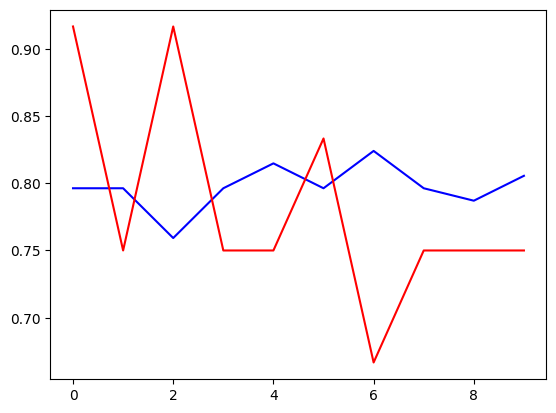

In [64]:
plt.plot(training_accuracy, color='blue')
plt.plot(validation_accuracy, color='red')

plt.show()

In [57]:
kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)

In [58]:
model = LogisticRegression()

In [59]:
overall_train = np.zeros(20)
overall_test = np.zeros(20)

for i in range(20):
    scores = np.zeros(10)

    for k, (train, test) in enumerate(kfold):
        model.fit(X_train[train], y_train[train])

        scores[k] = model.score(X_train[test], y_train[test])

    overall_train[i] = scores.mean()
    overall_test[i] = model.score(X_test, y_test)

In [61]:
overall_train

array([0.91666667, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

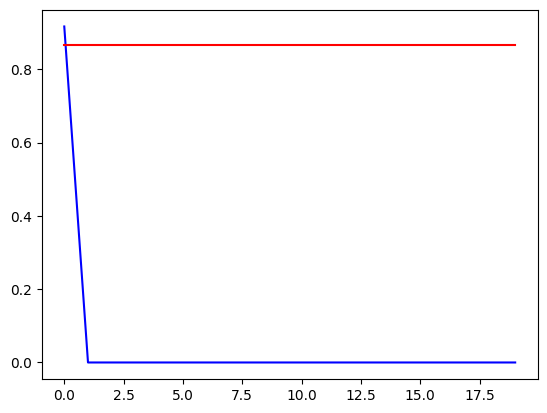

In [60]:
plt.plot(overall_train, color='blue')
plt.plot(overall_test, color='red')

plt.show()

In [ ]:
iris = iris[~(iris['species'] == 'setosa')].reset_index(drop=True)

iris_features = ['sepal_length', 'sepal_width',	'petal_length',	'petal_width']
iris_targets = ['species']
iris_species = ['versicolor', 'virginica']

iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,7.0,3.2,4.7,1.4,versicolor
1,6.4,3.2,4.5,1.5,versicolor
2,6.9,3.1,4.9,1.5,versicolor
3,5.5,2.3,4.0,1.3,versicolor
4,6.5,2.8,4.6,1.5,versicolor
...,...,...,...,...,...
95,6.7,3.0,5.2,2.3,virginica
96,6.3,2.5,5.0,1.9,virginica
97,6.5,3.0,5.2,2.0,virginica
98,6.2,3.4,5.4,2.3,virginica


In [99]:
# iris[iris_features] = (iris[iris_features] - iris[iris_features].mean(axis=0)) / iris[iris_features].std(axis=0)

iris[iris_features] = preprocessing.fit_transform(iris[iris_features])
iris[iris_targets] = iris[iris_targets].map(lambda x: {'versicolor': 0, 'virginica': 1}[x]).astype(dtype=pd.Int8Dtype())

iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,1.119009,0.990688,-0.250779,-0.653039,0
1,0.209246,0.990688,-0.494254,-0.416431,0
2,0.967382,0.688649,-0.007304,-0.416431,0
3,-1.155400,-1.727663,-1.102941,-0.889647,0
4,0.360873,-0.217468,-0.372516,-0.416431,0
...,...,...,...,...,...
95,0.664127,0.386610,0.357908,1.476436,1
96,0.057618,-1.123585,0.114433,0.530003,1
97,0.360873,0.386610,0.357908,0.766611,1
98,-0.094009,1.594766,0.601383,1.476436,1


In [59]:
feature_cov = iris[iris_features].cov()
feature_eigen = np.linalg.eig(feature_cov)

feature_eigen_vals = feature_eigen.eigenvalues
feature_eigen_vecs = feature_eigen.eigenvectors

desc_eigens_index = np.argsort(np.abs(feature_eigen_vals))[::-1]
desc_eigen_vecs = feature_eigen_vecs[:, desc_eigens_index]

k = 3
k_largest_eigens = desc_eigen_vecs[:, :k]

projection = iris[iris_features] @ k_largest_eigens

projection = projection.join(iris[iris_targets])

In [58]:
fig = px.scatter(projection, x=0, y=1, color='species')

fig.show()

In [60]:
import plotly.express as px

fig = px.scatter_3d(projection, x=0, y=1, z=2, color='species')

fig.show()

In [100]:
grouped_species = iris.groupby('species')

In [101]:
mean_vector = grouped_species.aggregate('mean')
mean_vector

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
0,-0.494305,-0.30808,-0.786424,-0.828129
1,0.494305,0.30808,0.786424,0.828129


In [103]:
within_scatter_matrix = np.zeros((4, 4))
per_group_scatter = grouped_species.apply('cov', include_groups=False)

for label in [0, 1]:
    within_scatter_matrix += per_group_scatter.loc[label].to_numpy()

In [104]:
overall_mean = mean_vector.mean()
between_scatter_matrix = np.zeros((4, 4))

for label in [0, 1]:
    n = len(iris[iris['species'] == label])

    diff = (mean_vector.loc[label] - overall_mean).to_numpy().reshape((-1, 1))

    between_scatter_matrix += (n * (diff @ diff.T))

In [105]:
temp = np.linalg.inv(within_scatter_matrix) @ between_scatter_matrix

In [106]:
eigvals, eigvecs = np.linalg.eigh(temp)

In [107]:
k = 2
lds = eigvals.argsort()[::-1]

ld_transformation = eigvecs[:, lds[: k]]

In [108]:
projection = iris[iris_features] @ ld_transformation

In [109]:
projection = projection.join(iris[iris_targets])

In [110]:
projection

,0,1,species
0,-0.077684,-0.348305,0
1,-0.360762,0.027596,0
2,0.139734,-0.337069,0
3,-1.982518,0.156743,0
4,-0.452858,-0.061918,0
...,...,...,...
95,1.472243,0.800667,1
96,0.235315,0.304525,1
97,0.918769,0.297085,1
98,1.627705,0.664448,1


In [ ]:
import plotly.express as px

fig = px.scatter_3d(projection, x=0, y=1, z=2, color='species')

fig.show()

In [111]:
fig = px.scatter(projection, x=0, y=1, color='species')

fig.show()

In [ ]:
np.log1p

Timedelta('1 days 00:00:00')

In [ ]:
perceptron = Perceptron(iris[iris_features], iris[iris_targets])
confusions = perceptron.fit(0.001, 5)

In [154]:
adeline = Adeline(projection[[0, 1]], projection[iris_targets])
train_loss, test_loss = adeline.fit(0.25, 20, 1)

In [2]:
import itertools

list(itertools.combinations(range(1, 4), 2))

[(1, 2), (1, 3), (2, 3)]

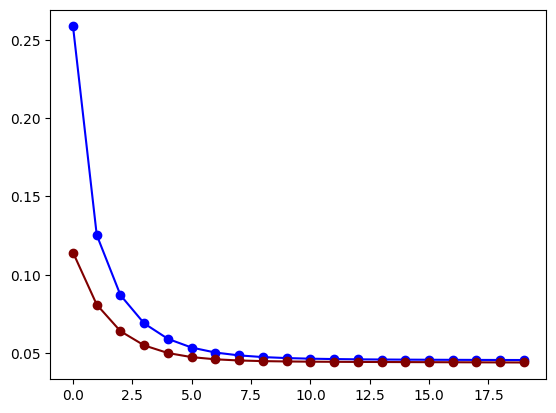

In [155]:
plt.plot(train_loss, marker='o', color='blue')
plt.plot(test_loss, marker='o', color='maroon')

plt.show()

In [166]:
logistic = LogisticRegression(projection[[0, 1]], projection[iris_targets])

train_loss, test_loss = logistic.fit(0.5, 50, batch_cut=1, l2=0)

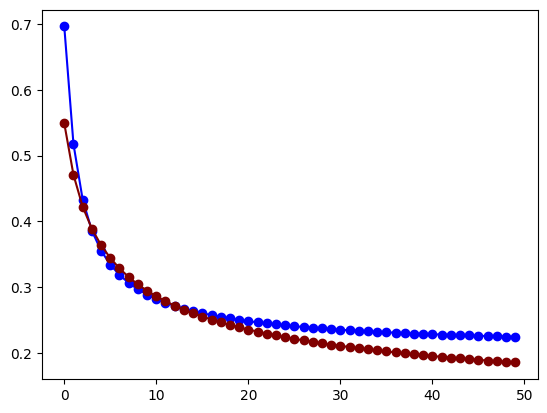

In [167]:
plt.plot(train_loss, marker='o', color='blue')
plt.plot(test_loss, marker='o', color='maroon')

plt.show()

In [35]:
rng = np.random.default_rng(seed=42)

random_indexes = rng.permutation(np.arange(len(iris)))

randomized_df = iris.iloc[random_indexes, :]

In [56]:
reference_count = int(len(iris) * 0.8)

reference_set = randomized_df.iloc[:reference_count, :].reset_index(drop=True)
test_set = randomized_df.iloc[reference_count:, :].reset_index(drop=True)

test_features = test_set[iris_features].to_numpy()
test_targets = test_set[iris_targets].to_numpy().reshape((1, -1))

predictions = np.zeros(len(test_set), dtype=np.int8)

distance = lambda x, y: np.sum(np.square(x - y), axis=1)

k = 10

for i in np.arange(len(test_set)):
    nearest_neighbors = distance(test_features[i, :], reference_set[iris_features]).sort_values().head(k).index

    predictions[i] = reference_set.loc[nearest_neighbors, [iris_targets]].mode().iat[0, 0]

misclassifications = np.count_nonzero(test_targets - predictions)

accuracy = ((len(test_targets) - misclassifications) / len(test_targets)) * 100
accuracy

ValueError: invalid literal for int() with base 10: 'setosa'

In [ ]:
pd.cut()

<module 'pandas.api' from 'c:\\Users\\pc\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\pandas\\api\\__init__.py'>

In [ ]:
class Clusterize:
    def __init__(self, dataframe, tso_log=False, sample_pct=1, random_state=42, scaler=None):

        self.dataframe = dataframe.copy()

        self.random_state = random_state

        self.scaler = scaler
        
        self.tso_df = self.__init_tso(log=tso_log, sample_pct=sample_pct)
        self.rfm_df = self.__init_rfm(log=tso_log, sample_pct=sample_pct)
        
    def __init_tso(self, *, log, sample_pct):
        tso_df = (self.dataframe.groupby('customer_unique_id')
                                   .aggregate({'payment_value': 'sum',
                                               'review_score': 'mean',
                                               'order_id': 'count'})
                                   .rename(columns={'payment_value': 'total_spent', 
                                                    'review_score': 'satisfaction', 
                                                    'order_id': 'order_count'}))
        if log:
            tso_df = np.log1p(tso_df)

        
        if 0 < sample_pct < 1:
            tso_df = tso_df.sample(frac=sample_pct, random_state=self.random_state)

        return tso_df
        
    def __init_rfm(self, *, log, sample_pct):
        snapshot_date = self.dataframe['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

        rfm_df = (self.dataframe.groupby('customer_unique_id')
                                  .agg({'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
                                        'order_id': 'count',
                                        'payment_value': 'sum',})
                                  .rename(columns={'order_purchase_timestamp': 'recency',
                                                   'order_id': 'frequency',
                                                   'payment_value': 'monetary'}))
        if log:
            rfm_df['monetary'] = np.log1p(rfm_df['monetary'])
            rfm_df['recency'] = np.log1p(rfm_df['recency'].max() - rfm_df['recency'])
            rfm_df['frequency'] = np.log1p(rfm_df['frequency'])

        
        if 0 < sample_pct < 1:
            rfm_df = rfm_df.sample(frac=sample_pct, random_state=self.random_state)

        return rfm_df

    def __jittered_umap(self, data: pd.DataFrame, *, 
                                 jitter_std: float,
                                 n_neighbors: int,
                                 min_dist: float,
                                 n_components: int):
    
        X = data.copy()
    
        X += np.random.normal(0, jitter_std, size=X.shape)
    
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=n_components,
            init='pca',
        )
    
        embedding = reducer.fit_transform(X)
        
        return embedding
    
    def __get_df(self, analysis='rfm'):
        match analysis.casefold():
            case 'tso':
                return self.tso_df

            case 'rfm':
                return self.rfm_df

        
    def clusterize(self, n_clusters, /, *, analysis='rfm'):
        df = self.__get_df(analysis).copy()

        if self.scaler:
            df = self.scaler.fit_transform(df)

        kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=self.random_state)
        clusters = kmeans.fit_predict(df)

        self.__get_df(analysis)['cluster'] = clusters

        sil_score = silhouette_score(df, self.__get_df(analysis)['cluster'])
        db_score = davies_bouldin_score(df, self.__get_df(analysis)['cluster'])

        return sil_score, db_score

    def draw_umap(self, *, projection_d=2, analysis='rfm'):
        df = self.__get_df(analysis).copy()
        
        if self.scaler:
            df = scaler.fit_transform(df)
        
        if analysis.casefold() == 'tso':
            df_umap = self.__jittered_umap(df,
                                            jitter_std = 0.001,
                                            n_neighbors = 15,
                                            min_dist = 0.1,
                                            n_components = projection_d)
            
        if analysis.casefold() == 'rfm':
            df_umap = self.__jittered_umap(df, 
                                            jitter_std = 0.005,
                                            n_neighbors = 30,
                                            min_dist = 0,
                                            n_components = 2,)
        
        match projection_d:
            case 2:        
                plt.figure(figsize=(12, 8))

                sns.scatterplot(x=df_umap[:,0], y=df_umap[:,1], hue=self.__get_df(analysis)['cluster'], palette='tab10')
                
                plt.xlabel("UMAP-1")
                plt.ylabel("UMAP-2")
                plt.title("Customer Segments (UMAP Projection)")
                plt.grid(True)
                plt.show()
                
            case 3:
                fig = px.scatter_3d(x=df_umap[:,0], y=df_umap[:,1], z=df_umap[:,2], color=self.__get_df(analysis)['cluster'])

                fig.show()

    def tso_profile(self, *, ranked=False):
        if 'cluster' not in self.tso_df.columns:
            self.clusterize(3, analysis='tso')

        cluster_profile = (self.tso_df.groupby('cluster')
                               .agg({'total_spent': 'mean',
                                     'satisfaction': 'mean',
                                     'order_count': 'mean',
                                     'cluster': 'count',})
                       
                               .rename(columns={'cluster': 'n'}))
        if ranked:
            return cluster_profile.rank()

        return cluster_profile
    
    def tso_profile(self, *, ranked=False):
        if 'cluster' not in self.tso_df.columns:
            self.clusterize(3, analysis='rfm')

        cluster_profile = (self.rfm_df.groupby('cluster')
                                .agg({'recency': 'mean',
                                        'frequency': 'mean',
                                        'monetary': 'mean',
                                        'cluster': 'count',})
                        
                                .rename(columns={'cluster': 'n'}))
        if ranked:
            return cluster_profile.rank(ascending=False)

        return cluster_profile
                

In [ ]:
analysis = 'tso'

sil_score, db_score = clusterizer.clusterize(3, analysis=analysis)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Score: {db_score:.4f}")

clusterizer.draw_umap(projection_d=2, analysis=analysis)

clusterizer.draw_umap(projection_d=3, analysis=analysis)

clusterizer.tso_profile()
clusterizer.tso_profile(ranked=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rng = np.random.default_rng()

In [4]:
def fib(n):
    a, b = 0, 1
    fibs = []

    for _ in range(n):
        a, b = a + b, a

        fibs.append(a)

    return fibs    

In [5]:
fibs = np.array(list(map(lambda x: -1*x, fib(10))) + [0] + fib(10))

In [6]:
random_walk = rng.choice(fibs, 1_000_000).cumsum()

cum_average = random_walk / np.arange(1, len(random_walk) + 1)

In [18]:
window_size = 100_000
moving_average_llarge = np.convolve(random_walk, np.ones(window_size)/window_size, mode='valid')

In [7]:
window_size = 10_000
moving_average_large = np.convolve(random_walk, np.ones(window_size)/window_size, mode='valid')

In [8]:
window_size = 1_000
moving_average_medium = np.convolve(random_walk, np.ones(window_size)/window_size, mode='valid')

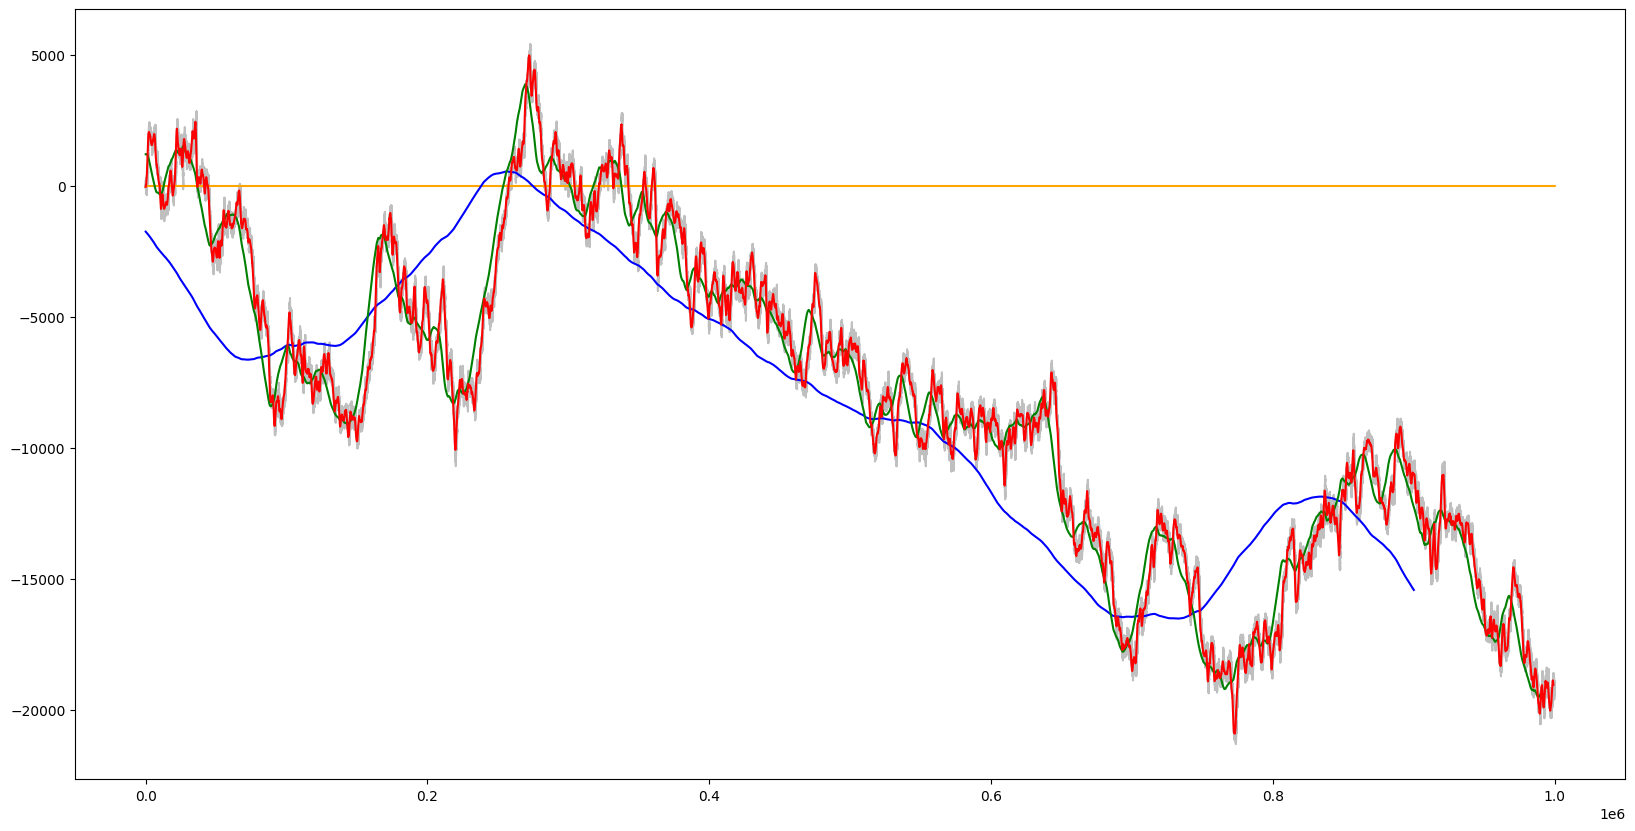

In [20]:
plt.figure(figsize=(20, 10))
plt.plot(random_walk, color='grey', alpha=0.5)
plt.plot(cum_average, color='orange')
plt.plot(moving_average_llarge, color='blue')
plt.plot(moving_average_large, color='green')
plt.plot(moving_average_medium, color='red')
plt.show()

In [49]:
np.arange()

TypeError: arange() requires stop to be specified.

In [50]:
from collections import defaultdict


dd = defaultdict()

In [52]:
dd[0] = 1

In [56]:
dd.setdefault(int, 0)

0

In [57]:
print(dd.get(1))

None


In [9]:
import numpy as np

np.meshgrid(np.arange(8), np.arange(8))

[array([[0, 1, 2, 3, 4, 5, 6, 7],
        [0, 1, 2, 3, 4, 5, 6, 7],
        [0, 1, 2, 3, 4, 5, 6, 7],
        [0, 1, 2, 3, 4, 5, 6, 7],
        [0, 1, 2, 3, 4, 5, 6, 7],
        [0, 1, 2, 3, 4, 5, 6, 7],
        [0, 1, 2, 3, 4, 5, 6, 7],
        [0, 1, 2, 3, 4, 5, 6, 7]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4, 4, 4, 4],
        [5, 5, 5, 5, 5, 5, 5, 5],
        [6, 6, 6, 6, 6, 6, 6, 6],
        [7, 7, 7, 7, 7, 7, 7, 7]])]

In [10]:
import numpy as np
import matplotlib.pyplot as plt

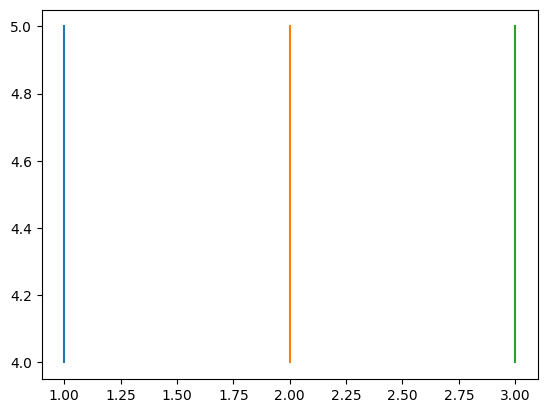

In [17]:


x = np.array([1, 2, 3])
y = np.array([4, 5])

X, Y = np.meshgrid(x, y)


plt.plot(X, Y)


In [20]:
a = np.arange(64).reshape(8, 8)

In [24]:
np.size(a)

64

In [25]:
import itertools

In [34]:
a = [1]

In [35]:
assert a, 'HOHOOO'

In [28]:
list(itertools.product([3, 5, 7], range(4, 33), [4]))

[(3, 4, 4),
 (3, 5, 4),
 (3, 6, 4),
 (3, 7, 4),
 (3, 8, 4),
 (3, 9, 4),
 (3, 10, 4),
 (3, 11, 4),
 (3, 12, 4),
 (3, 13, 4),
 (3, 14, 4),
 (3, 15, 4),
 (3, 16, 4),
 (3, 17, 4),
 (3, 18, 4),
 (3, 19, 4),
 (3, 20, 4),
 (3, 21, 4),
 (3, 22, 4),
 (3, 23, 4),
 (3, 24, 4),
 (3, 25, 4),
 (3, 26, 4),
 (3, 27, 4),
 (3, 28, 4),
 (3, 29, 4),
 (3, 30, 4),
 (3, 31, 4),
 (3, 32, 4),
 (5, 4, 4),
 (5, 5, 4),
 (5, 6, 4),
 (5, 7, 4),
 (5, 8, 4),
 (5, 9, 4),
 (5, 10, 4),
 (5, 11, 4),
 (5, 12, 4),
 (5, 13, 4),
 (5, 14, 4),
 (5, 15, 4),
 (5, 16, 4),
 (5, 17, 4),
 (5, 18, 4),
 (5, 19, 4),
 (5, 20, 4),
 (5, 21, 4),
 (5, 22, 4),
 (5, 23, 4),
 (5, 24, 4),
 (5, 25, 4),
 (5, 26, 4),
 (5, 27, 4),
 (5, 28, 4),
 (5, 29, 4),
 (5, 30, 4),
 (5, 31, 4),
 (5, 32, 4),
 (7, 4, 4),
 (7, 5, 4),
 (7, 6, 4),
 (7, 7, 4),
 (7, 8, 4),
 (7, 9, 4),
 (7, 10, 4),
 (7, 11, 4),
 (7, 12, 4),
 (7, 13, 4),
 (7, 14, 4),
 (7, 15, 4),
 (7, 16, 4),
 (7, 17, 4),
 (7, 18, 4),
 (7, 19, 4),
 (7, 20, 4),
 (7, 21, 4),
 (7, 22, 4),
 (7, 23, 4),
 (7,